# Big Data Project: Wetter- und Luftqualitätsdaten

## Einleitung

Dieses Projekt sammelt Wetter- und Luftqualitätsdaten, speichert die Rohdaten lokal als JSON und legt sie zusätzlich in MongoDB ab.

**Ziel des ersten Setups:**
- Python-Abhängigkeiten installieren
- Projektordner vorbereiten
- `.env` und MongoDB-Verbindung prüfen
- das Projekt mit `src.main` starten

**Aktueller Ablauf im Projekt:**
1. Wetterdaten laden
2. Luftqualitätsdaten laden
3. Rohdaten in `data/raw/...` speichern
4. Daten in MongoDB-Collections ablegen


## Setup

Vor dem Start bitte sicherstellen:
- Python 3 und ein aktives Projekt-Environment
- Docker bzw. Docker Desktop laeuft
- `docker compose` ist verfuegbar
- die folgende Setup-Zelle wird vor `src.main` ausgefuehrt

Die Setup-Zelle:
1. wechselt ins Projektverzeichnis
2. legt `.env` aus `.env.example` an, falls noetig
3. lädt die benoetigten Umgebungsvariablen
4. prüft Docker
5. startet den MongoDB-Container aus `docker-compose.yml`

Verwendete Standardwerte für `.env`:

```env
MONGO_URI=mongodb://localhost:27017/
MONGO_DB=big_data_weather_airpollution
WEATHER_API_KEY=
WEATHER_USE_MOCK=true
WEATHER_LAT=48.2082
WEATHER_LON=16.3738
WEATHER_UNITS=metric
WEATHER_LANG=de
WEATHER_EXCLUDE=minutely,alerts
AIR_QUALITY_API_KEY=
OPENAQ_LOCATION_ID=8118
```


### Abhängigkeiten prüfen

Die folgende Zelle prüft die benötigten Python-Pakete für das Notebook und aktiviert sie bei Bedarf. Die Hilfsmethode liegt in `src/notebook_methods.py` als `ensure_notebook_dependencies()`.


In [25]:
from src.notebook_methods import ensure_notebook_dependencies

ensure_notebook_dependencies()


HTTP-Anfragen: verfügbar und aktiv
MongoDB-Anbindung: verfügbar und aktiv
Umgebungsvariablen: verfügbar und aktiv
Matplotlib: verfügbar und aktiv
Pandas: verfügbar und aktiv


**Hinweis:** Wenn `docker` oder `docker compose` nicht gefunden wird, bitte sicherstellen, dass Docker Desktop installiert und gestartet ist. Unter Linux muss eventuell der Docker-Daemon mit `sudo systemctl start docker` gestartet werden.

### Docker-Erreichbarkeit prüfen

Die folgende Zelle testet, ob Docker grundsätzlich erreichbar ist, bevor Container gestartet werden. Die Prüfung läuft direkt in dieser Notebook-Zelle.


In [10]:
import subprocess

subprocess.run(
    ["docker", "ps"],
    check=True,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)
print("Docker ist erreichbar.")

Docker ist erreichbar.


### Notebook-Umgebung vorbereiten

Die folgende Zelle setzt das Arbeitsverzeichnis, lädt die `.env`-Werte und startet den MongoDB-Container. Die Hilfsmethode liegt in `src/notebook_methods.py` als `prepare_notebook_environment()`.


In [11]:
from src.notebook_methods import prepare_notebook_environment

project_dir = prepare_notebook_environment()


Arbeitsverzeichnis: /home/dg/.config/JetBrains/DataSpell2026.1/projects/workspace
.env bereits vorhanden
MONGO_URI=mongodb://localhost:27017/
MONGO_DB=big_data_weather_airpollution
MongoDB-Container laeuft.


### Datenordner anlegen

Die folgende Zelle stellt sicher, dass die Ordner `data/raw/weather`, `data/raw/air_quality` und `data/processed` vorhanden sind. Die Logik liegt direkt in dieser Notebook-Zelle.


In [12]:
from pathlib import Path

folders = [
    Path("data/raw/weather"),
    Path("data/raw/air_quality"),
    Path("data/processed"),
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)
    print(f"Ordner bereit: {folder}")


.env gefunden
MONGO_URI=mongodb://localhost:27017/
MONGO_DB=big_data_weather_airpollution
WEATHER_API_KEY=gesetzt
AIR_QUALITY_API_KEY=gesetzt


### Environment-Konfiguration anzeigen

Die folgende Zelle zeigt die wichtigsten `.env`-Einstellungen an und maskiert den Zustand der API-Keys. Die Hilfsmethode liegt in `src/notebook_methods.py` als `show_notebook_env_settings()`.


In [13]:
from src.notebook_methods import show_notebook_env_settings

show_notebook_env_settings()


.env gefunden
MONGO_URI=mongodb://localhost:27017/
MONGO_DB=big_data_weather_airpollution
WEATHER_API_KEY=gesetzt
AIR_QUALITY_API_KEY=gesetzt


## Projektstart

Die nächste Zelle startet den aktuellen Einstiegspunkt `src.main` mit demselben Python-Interpreter wie das Notebook. Dabei werden Beispiel-Datensätze erzeugt, lokal gespeichert und in MongoDB geschrieben.


### Datenerhebung ausführen

Die folgende Zelle startet den Projekteinstiegspunkt `src.main`, ruft Wetter- und Luftqualitätsdaten ab und speichert die Rohdaten lokal sowie in MongoDB.


In [2]:
import subprocess
import sys

_ = subprocess.run([sys.executable, "-m", "src.main"], cwd=project_dir, check=True)


Starte Datenabholung...
Wetterdaten von OpenWeather gespeichert.
Luftqualitaetsdaten von OpenAQ gespeichert.
Daten in Datenbank uebertragen.
Prozess abgeschlossen.


## MapReduce

Die naechsten Zellen zeigen zuerst die flach vorbereiteten Rohdaten, fuehren danach explizit die **MapReduce**-Pipeline aus und stellen anschliessend die verarbeiteten Daten als Tabelle dar.


### MapReduce-Rohdaten darstellen

Die folgende Zelle zeigt die für MapReduce flach vorbereiteten Rohdaten als Tabelle. Die Hilfsmethode liegt in `src/notebook_methods.py` als `render_MapReduce_raw_table()`.


In [1]:
from src.notebook_methods import render_MapReduce_raw_table

render_MapReduce_raw_table()


Stadt,Datum,Zeitpunkt,Temperatur (°C),Wetter,Luftqualitaet,Einheit,Fehlendes Wetter,Fehlende Luftqualitaet
Vienna,2025-01-01,2025-01-01T12:00:00+01:00,-0.24,Mäßig bewölkt,29.5,µg/m³,nein,nein
Vienna,2025-01-27,2025-01-27T12:00:00+01:00,8.30,Bedeckt,11.5,µg/m³,nein,nein
Vienna,2025-02-22,2025-02-22T12:00:00+01:00,5.75,Klarer Himmel,31.2,µg/m³,nein,nein
Vienna,2025-03-20,2025-03-20T12:00:00+01:00,10.76,Klarer Himmel,-1.0,µg/m³,nein,nein
Vienna,2025-04-15,2025-04-15T12:00:00+02:00,15.38,Leichter Regen,10.7,µg/m³,nein,nein
Vienna,2025-05-11,2025-05-11T12:00:00+02:00,15.91,Überwiegend bewölkt,5.33,µg/m³,nein,nein
Vienna,2025-06-06,2025-06-06T12:00:00+02:00,26.44,Ein paar Wolken,4.11,µg/m³,nein,nein
Vienna,2025-07-02,2025-07-02T12:00:00+02:00,29.57,Klarer Himmel,-1.0,µg/m³,nein,nein
Vienna,2025-07-28,2025-07-28T12:00:00+02:00,20.79,Bedeckt,5.45,µg/m³,nein,nein
Vienna,2025-08-23,2025-08-23T12:00:00+02:00,19.44,Bedeckt,3.34,µg/m³,nein,nein


### MapReduce ausfuehren

Die folgende **MapReduce**-Codezeile startet die Verarbeitung, ergänzt fehlende numerische Werte mit **Durchschnitt aus vorherigem und naechstem Zeitpunkt** und schreibt das Ergebnis nach `data/processed/`.


### MapReduce-Pipeline starten

Die folgende Zelle führt die explizite MapReduce-Verarbeitung aus. Die Pipeline liegt in `src/MapReduce.py` und ergänzt fehlende numerische Werte per Nachbar-Mittelwert.


In [2]:
from src.MapReduce import run_MapReduce_pipeline; mapreduce_result = run_MapReduce_pipeline()


MapReduce verarbeitet: 45 Rohdatensaetze.
MapReduce gespeichert: data/processed/MapReduce_20260422_202115.json


### MapReduce Processed Data

Hier steht die verarbeitete **MapReduce**-Ausgabe mit den ergaenzten Werten. `ja` markiert die Stellen, an denen ein fehlender Wert per Nachbar-Mittelwert imputiert wurde.


### Verarbeitete MapReduce-Daten anzeigen

Die folgende Zelle zeigt die verarbeiteten Daten inklusive Imputationsmarkierung an. Die Hilfsmethode liegt in `src/notebook_methods.py` als `render_MapReduce_processed_table()`.


In [3]:
from src.notebook_methods import render_MapReduce_processed_table

render_MapReduce_processed_table(mapreduce_result)


Stadt,Datum,Zeitpunkt,Temperatur (°C),Wetter,Luftqualitaet,Einheit,Temperatur imputiert,Luftqualitaet imputiert
Vienna,2025-01-01,2025-01-01T12:00:00+01:00,-0.24,Mäßig bewölkt,29.50,µg/m³,nein,nein
Vienna,2025-01-27,2025-01-27T12:00:00+01:00,8.30,Bedeckt,11.50,µg/m³,nein,nein
Vienna,2025-02-22,2025-02-22T12:00:00+01:00,5.75,Klarer Himmel,31.20,µg/m³,nein,nein
Vienna,2025-03-20,2025-03-20T12:00:00+01:00,10.76,Klarer Himmel,-1.00,µg/m³,nein,nein
Vienna,2025-04-15,2025-04-15T12:00:00+02:00,15.38,Leichter Regen,10.70,µg/m³,nein,nein
Vienna,2025-05-11,2025-05-11T12:00:00+02:00,15.91,Überwiegend bewölkt,5.33,µg/m³,nein,nein
Vienna,2025-06-06,2025-06-06T12:00:00+02:00,26.44,Ein paar Wolken,4.11,µg/m³,nein,nein
Vienna,2025-07-02,2025-07-02T12:00:00+02:00,29.57,Klarer Himmel,-1.00,µg/m³,nein,nein
Vienna,2025-07-28,2025-07-28T12:00:00+02:00,20.79,Bedeckt,5.45,µg/m³,nein,nein
Vienna,2025-08-23,2025-08-23T12:00:00+02:00,19.44,Bedeckt,3.34,µg/m³,nein,nein


## Datenvisualisierung
In den nächsten Zellen werden die in MongoDB gespeicherten Daten geladen und mit `pandas` und `matplotlib` visualisiert. Es werden einfache Zeitreihenplots der Wetter- und Luftqualitaetsdaten erstellt.

Zunächst importieren wir pandas zur Datenverarbeitung und matplotlib für die Visualisierung. Außerdem importieren wir die Funktion `get_database` aus unserem MongoDB-Client-Modul, um eine Verbindung zur Datenbank herzustellen und die Daten zu laden. Danach werden die Daten aus der Datenbank geladen und in einem DataFrame gespeichert, um sie für die Visualisierung vorzubereiten.

### Visualisierungsdaten laden

Die folgende Zelle lädt `pandas`, `matplotlib` und das neueste Wetterdokument aus MongoDB. Die Datenbankverbindung kommt aus `src/db/mongo_client.py` über `get_database()`.


In [15]:
import matplotlib.pyplot as plt
import pandas as pd
from src.db.mongo_client import get_database
db = get_database()
weather_collection = db["weather_raw"]
weather_doc = weather_collection.find_one(sort=[("_id", -1)])



Anschließend werden die stündlichen Wetterdaten aus dem geladenen Dokument extrahiert und in einem DataFrame organisiert. Falls die Daten im Unix-Zeitformat vorliegen, werden sie in ein lesbares Datumsformat konvertiert. Schließlich wird ein Zeitreihenplot der stündlichen Temperaturen erstellt, um die Entwicklung der Temperaturen über die Zeit zu visualisieren.

### Wetter-Zeitreihe plotten

Die folgende Zelle wandelt die geladenen Wetterdaten in ein DataFrame um und erstellt daraus einen Temperatur-Zeitreihenplot. Die Auswertelogik liegt direkt in dieser Notebook-Zelle.


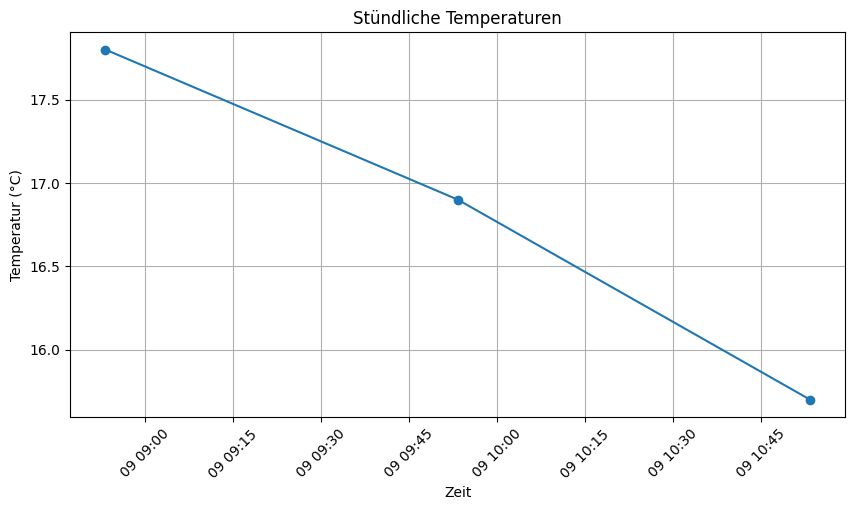

In [16]:
if weather_doc:
    weather_data = weather_doc["data"]
    hourly_df = pd.DataFrame(weather_data.get("hourly", []))
    if not hourly_df.empty:
        # Zeitstempel konvertieren (falls Unix-Zeit)
        hourly_df['dt'] = pd.to_datetime(hourly_df['dt'], unit='s')
        # Plot
        plt.figure(figsize=(10, 5))
        plt.plot(hourly_df['dt'], hourly_df['temp'], marker='o', linestyle='-')
        plt.title('Stündliche Temperaturen')
        plt.xlabel('Zeit')
        plt.ylabel('Temperatur (°C)')
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.show()
    else:
        print("Keine stündlichen Daten verfügbar.")
else:
    print("Keine Wetterdaten gefunden.")

Um zur eigentlichen Fragestellung zurückzukommen, also ob die Luftqualität in Wien in einem Zusammenhang mit der Temparatur steht, laden wir nun sowohl die Luftqualotät als auch die Temparaturen. Dazu werden die Daten aus den entsprechenden MongoDB-Collections geladen und in DataFrames organisiert. Anschließend werden die Daten zusammengeführt, um die Beziehung zwischen Temperatur und Luftqualität zu analysieren. Schließlich wird ein Streudiagramm erstellt, um die Korrelation zwischen den beiden Variablen zu visualisieren. //note:werde das nochmals versuchen, um an Daten zu kommen

### Wetter und Luftqualität gemeinsam visualisieren

Die folgende Zelle lädt Wetter- und Luftqualitätsdaten aus MongoDB, führt sie zeitlich zusammen und zeichnet einen kombinierten Vergleichsplot. Die Datenbankanbindung läuft über `src/db/mongo_client.py`.


In [17]:
import matplotlib.pyplot as plt
import pandas as pd
from src.db.mongo_client import get_database

db = get_database()
weather_collection = db["weather_raw"]
air_quality_collection = db["air_quality_raw"]
weather_doc = weather_collection.find_one(sort=[("_id", -1)])
air_doc = air_quality_collection.find_one(sort=[("_id", -1)])

if weather_doc and air_doc:
    weather_data = weather_doc["data"]
    air_data = air_doc["data"]

    hourly_df = pd.DataFrame(weather_data.get("hourly", []))
    if not hourly_df.empty:
        hourly_df['dt'] = pd.to_datetime(hourly_df['dt'], unit='s')
        if 'results' in air_data and air_data['results']:
            measurements = []
            for m in air_data.get('measurements', []):
                if m.get('parameter') == 'pm25':
                    measurements.append({
               'date': pd.to_datetime(m['date']['utc']),
               'value': m['value']
                        })
            air_df = pd.DataFrame(measurements)

            if not air_df.empty:
                air_df['hour'] = air_df['date'].dt.floor('H')
                air_hourly = air_df.groupby('hour')['value'].mean().reset_index()
                combined_df = pd.merge(hourly_df, air_hourly, left_on='dt', right_on='hour', how='left')
                fig, ax1 = plt.subplots(figsize=(12, 6))

                ax1.plot(combined_df['dt'], combined_df['temp'], color='red', marker='o', label='Temperatur (°C)')
                ax1.set_xlabel('Zeit')
                ax1.set_ylabel('Temperatur (°C)', color='red')
                ax1.tick_params(axis='y', labelcolor='red')
                ax1.set_title('Temperatur und Luftqualität (PM2.5) über Zeit')


                ax2 = ax1.twinx()
                ax2.bar(combined_df['dt'], combined_df['value'], alpha=0.5, color='blue', label='PM2.5 (µg/m³)', width=0.02)
                ax2.set_ylabel('PM2.5 (µg/m³)', color='blue')
                ax2.tick_params(axis='y', labelcolor='blue')

                lines, labels = ax1.get_legend_handles_labels()
                bars, bar_labels = ax2.get_legend_handles_labels()
                ax1.legend(lines + bars, labels + bar_labels, loc='upper left')

                plt.xticks(rotation=45)
                plt.grid(True, alpha=0.3)
                plt.show()
            else:
                print("Keine PM2.5-Daten gefunden.")
        else:
            print("Luftqualitätsdaten-Struktur prüfen.")
    else:
        print("Keine stündlichen Wetterdaten verfügbar.")
else:
    print("Daten nicht verfügbar.")

Keine PM2.5-Daten gefunden.


## Aufraeumen und herunterfahren

Wenn du am Ende wieder ein sauberes System haben willst, kannst du zuerst den MongoDB-Container samt Compose-Ressourcen stoppen. Das Beenden von Docker Desktop ist optional und betrifft alle laufenden Docker-Container.


### Umgebung aufräumen

Die folgende Zelle stoppt den MongoDB-Container und räumt die Docker-Compose-Ressourcen auf. Die Befehle liegen direkt in dieser Notebook-Zelle.


In [18]:
import subprocess

subprocess.run(["docker", "compose", "down"], cwd=project_dir, check=True)
print("MongoDB-Container und Compose-Ressourcen wurden gestoppt.")

# Optional unter Linux mit Docker Desktop als User-Service:
# subprocess.run(["systemctl", "--user", "stop", "docker-desktop"], check=True)
# print("Docker Desktop wurde gestoppt.")


MongoDB-Container und Compose-Ressourcen wurden gestoppt.
